[1]

In [1]:
from ISLP import load_data #install it first with the command: !pip install ISLP
Auto = load_data('Auto')   #load any of the datasets in the book
Auto[:10]                  #look at the first few rows of data

ModuleNotFoundError: No module named 'ISLP'

[2]

In [2]:
import numpy as np
import pandas as pd

Auto = load_data('Auto')

Auto.dtypes

mpg             float64
cylinders         int64
displacement    float64
horsepower        int64
weight            int64
acceleration    float64
year              int64
origin            int64
dtype: object

In [3]:
# Pick only numeric columns (drop the index "name" automatically)
num_cols = Auto.select_dtypes(include=[np.number]).columns
Auto_num = Auto[num_cols]

summary = pd.DataFrame({
    "min": Auto_num.min(),
    "max": Auto_num.max(),
    "median": Auto_num.median(),
    "mean": Auto_num.mean(),
    "std": Auto_num.std(),
    "unique": Auto_num.nunique()
})

summary

,min,max,median,mean,std,unique
mpg,9.0,46.6,22.75,23.445918,7.805007,127
cylinders,3.0,8.0,4.00,5.471939,1.705783,5
displacement,68.0,455.0,151.00,194.411990,104.644004,81
horsepower,46.0,230.0,93.50,104.469388,38.491160,93
weight,1613.0,5140.0,2803.50,2977.584184,849.402560,346
acceleration,8.0,24.8,15.50,15.541327,2.758864,95
year,70.0,82.0,76.00,75.979592,3.683737,13
origin,1.0,3.0,1.00,1.576531,0.805518,3


I excluded the name column because it isn't a numeric value

[3]

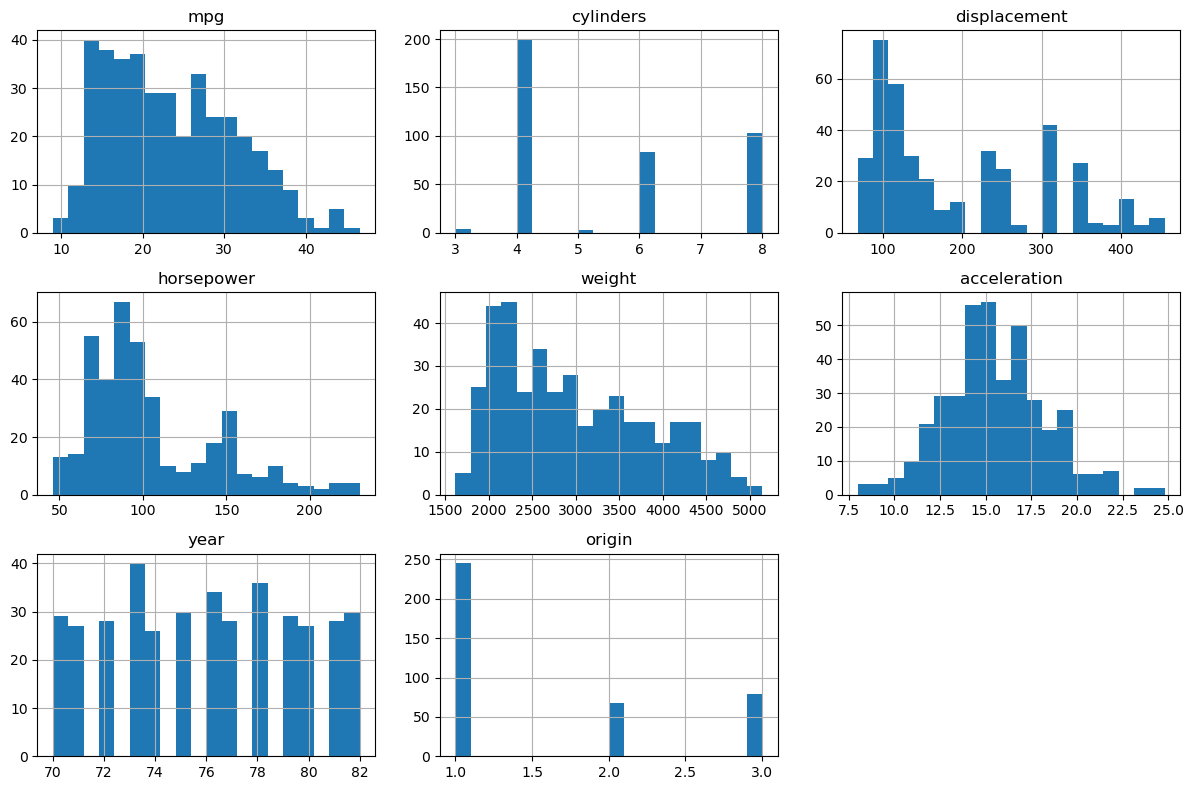

In [4]:
import matplotlib.pyplot as plt

Auto_num.hist(figsize=(12, 8), bins=20)
plt.tight_layout()
plt.show()

I think the accerleration is the most interesting column vector becuase I like how it is concentrated in the middle sort of like a bell curve in a way.

[4]

In [5]:
corr = Auto_num.corr()
corr

,mpg,cylinders,displacement,horsepower,weight,acceleration,year,origin
mpg,1.000000,-0.777618,-0.805127,-0.778427,-0.832244,0.423329,0.580541,0.565209
cylinders,-0.777618,1.000000,0.950823,0.842983,0.897527,-0.504683,-0.345647,-0.568932
displacement,-0.805127,0.950823,1.000000,0.897257,0.932994,-0.543800,-0.369855,-0.614535
horsepower,-0.778427,0.842983,0.897257,1.000000,0.864538,-0.689196,-0.416361,-0.455171
weight,-0.832244,0.897527,0.932994,0.864538,1.000000,-0.416839,-0.309120,-0.585005
acceleration,0.423329,-0.504683,-0.543800,-0.689196,-0.416839,1.000000,0.290316,0.212746
year,0.580541,-0.345647,-0.369855,-0.416361,-0.309120,0.290316,1.000000,0.181528
origin,0.565209,-0.568932,-0.614535,-0.455171,-0.585005,0.212746,0.181528,1.000000


In [14]:
corr_mat = corr

mask = np.triu(np.ones(corr_mat.shape), k=1).astype(bool)
pairs = corr_mat.where(mask).stack()

pairs_df = pairs.reset_index()
pairs_df.columns = ["var1", "var2", "corr"]

top_pos = pairs_df.sort_values("corr", ascending=False).head(10)
top_neg = pairs_df.sort_values("corr", ascending=True).head(10)

top_pos, top_neg


(            var1          var2      corr
 10     cylinders  displacement  0.950823
 20  displacement        weight  0.932994
 12     cylinders        weight  0.897527
 19  displacement    horsepower  0.897257
 28    horsepower        weight  0.864538
 11     cylinders    horsepower  0.842983
 6            mpg          year  0.580541
 7            mpg        origin  0.565209
 5            mpg  acceleration  0.423329
 46  acceleration          year  0.290316,
             var1          var2      corr
 4            mpg        weight -0.832244
 2            mpg  displacement -0.805127
 3            mpg    horsepower -0.778427
 1            mpg     cylinders -0.777618
 29    horsepower  acceleration -0.689196
 23  displacement        origin -0.614535
 39        weight        origin -0.585005
 15     cylinders        origin -0.568932
 21  displacement  acceleration -0.543800
 13     cylinders  acceleration -0.504683)

In [7]:
np.corrcoef(Auto["mpg"], Auto["cylinders"])[0,1]

-0.7776175081260214

- close to 1: strong positive linear relationship
- close to -1: strong negative linear relationship
- close to 0: not much linear relationship

[extra credit]

In [8]:
corr["horsepower"].sort_values(key=lambda s: s.abs(), ascending=False)

horsepower      1.000000
displacement    0.897257
weight          0.864538
cylinders       0.842983
mpg            -0.778427
acceleration   -0.689196
origin         -0.455171
year           -0.416361
Name: horsepower, dtype: float64

Weight, displacement, and cylinders have the best correlation with horsepower